## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import pydeck as pdk

df = duckdb.sql("""
SELECT
    starttime,
    stoptime,
    "start station latitude" AS start_lat,
    "start station longitude" AS start_lon,
    "end station latitude" AS end_lat,
    "end station longitude" AS end_lon,
    gender
FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
WHERE random() < 0.05""").df()

df.head()

,starttime,stoptime,start_lat,start_lon,end_lat,end_lon,gender
0,1/1/2015 0:07,1/1/2015 0:09,40.748549,-73.988084,40.745168,-73.986831,1
1,1/1/2015 0:09,1/1/2015 0:23,40.762272,-73.987882,40.756458,-73.993722,1
2,1/1/2015 0:13,1/1/2015 0:25,40.760203,-73.964785,40.739126,-73.979738,1
3,1/1/2015 0:44,1/1/2015 1:32,40.683125,-73.978951,40.712733,-74.004607,0
4,1/1/2015 0:51,1/1/2015 1:00,40.759291,-73.988597,40.755942,-74.002116,1


In [2]:
# Veri setindeki hatali veya eksik zaman formatlarini ayiklamak icin errors="coerce" kullaniyoruz
df["start_at"] = pd.to_datetime(df["starttime"], errors="coerce", format="mixed")
df["stop_at"] = pd.to_datetime(df["stoptime"], errors="coerce", format="mixed")

df["duration_min"] = (df["stop_at"] - df["start_at"]).dt.total_seconds() / 60
# Outlierlari filtrelemek icin suresi 1 dk alti ve 120 dk ustu olan satirlari cikarmiyoruz
df = df[(df["duration_min"] >= 1) & (df["duration_min"] <= 120)].copy()
df.dropna(inplace=True)

In [3]:
df["hour_of_day"] = df["start_at"].dt.hour
df["day_of_week"] = df["start_at"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

def calculate_manhattan(lat1, lon1, lat2, lon2):
# 1 enlem derecesi ~111 km, boylam ise ~111 km * cos(latitude) formuluyle yaklasik Manhattan mesafesi hesaplanir
    # 1 degree of latitude is ~111 km
    # 1 degree of longitude is ~111 km * cos(latitude)
    lat_diff = np.abs(lat2 - lat1) * 111.0
    lon_diff = np.abs(lon2 - lon1) * 111.0 * np.cos(np.radians((lat1 + lat2) / 2))
    return lat_diff + lon_diff

df["distance_km"] = calculate_manhattan(df["start_lat"], df["start_lon"], df["end_lat"], df["end_lon"])

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ["distance_km", "hour_of_day", "day_of_week", "is_weekend"]
X = df[features]
y = df["duration_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ilk adim olarak temel bir Linear Regression modeli kurulmustur
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Evaluation:")
print("Bias (Intercept):", model.intercept_)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Model Evaluation:
Bias (Intercept): 11.938696844037413
MAE: 7.583514929627276
RMSE: 10.847696725609554
R2 Score: 0.01011119243673464


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

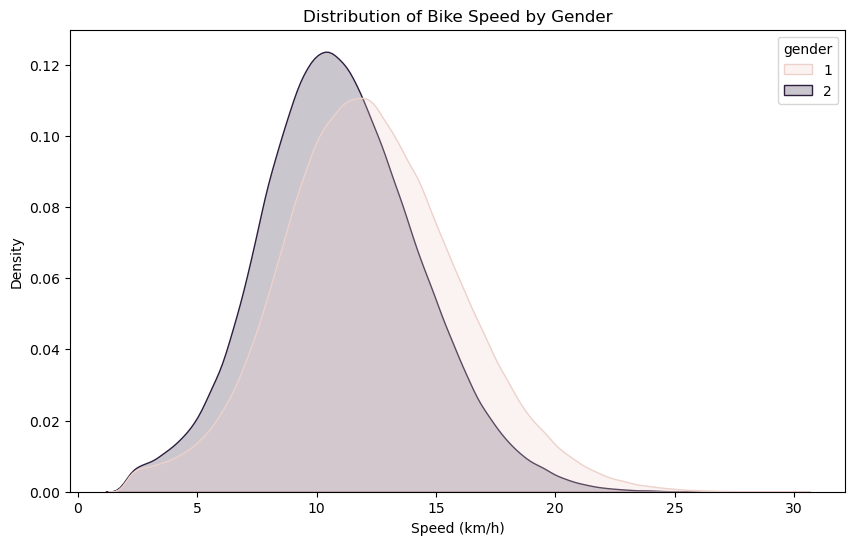

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate bike speed in km/h
df["speed_kmh"] = df["distance_km"] / (df["duration_min"] / 60)

# Clean up extreme values and focus on known genders (1 and 2 usually mean male and female in this dataset)
nb_df = df[(df["gender"].isin([1, 2])) & (df["speed_kmh"] >= 2) & (df["speed_kmh"] <= 30)].copy()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=nb_df, x="speed_kmh", hue="gender", common_norm=False, fill=True)
plt.title("Distribution of Bike Speed by Gender")
plt.xlabel("Speed (km/h)")
plt.ylabel("Density")
plt.show()

Yukarıdaki KDE grafiğinde de görebileceğimiz üzere, speed_kmh sürekli değişkeni her iki cinsiyet için de kabaca normal bir dağılım izlemektedir.Bu nedenle, P(speed_{bike} = x | gender = a) ifadesi bir Gauss dağılımı kullanılarak modellenebilir.

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

X_nb = nb_df[["speed_kmh"]]
y_nb = nb_df["gender"]

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train_nb, y_train_nb)

y_pred_nb = gnb.predict(X_test_nb)

print("Accuracy:", accuracy_score(y_test_nb, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test_nb, y_pred_nb))

Accuracy: 0.7602818649175678

Classification Report:
               precision    recall  f1-score   support

           1       0.76      1.00      0.86    154395
           2       0.00      0.00      0.00     48681

    accuracy                           0.76    203076
   macro avg       0.38      0.50      0.43    203076
weighted avg       0.58      0.76      0.66    203076



/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
